In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Генерация датасетов

In [3]:
ISU = 465572

X_moons, y_moons = make_moons(
    n_samples=400,
    noise=0.15,
    random_state=ISU
)

X_class, y_class = make_classification(
    n_samples=200,
    n_features=5,
    n_redundant=2,
    random_state=ISU,
    n_informative=2,
    n_clusters_per_class=2,
    n_classes=2
)

print("make_moons:", X_moons.shape, y_moons.shape)
print("make_classification:", X_class.shape, y_class.shape)

make_moons: (400, 2) (400,)
make_classification: (200, 5) (200,)


## Функция разделения данных 60/20/20

In [4]:
def split_and_scale(X, y, random_state):
    # сначала отделяем тест 20%
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=random_state,
        stratify=y
    )

    # из оставшихся 80% отделяем валидацию 20% от всего датасета
    # 20 / 80 = 0.25
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=0.25,
        random_state=random_state,
        stratify=y_temp
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    y_train = y_train.reshape(-1, 1)
    y_val = y_val.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)

    return X_train, X_val, X_test, y_train, y_val, y_test, scaler


moons_data = split_and_scale(X_moons, y_moons, ISU)
class_data = split_and_scale(X_class, y_class, ISU)

print("Moons:")
print("train:", moons_data[0].shape, "val:", moons_data[1].shape, "test:", moons_data[2].shape)

print("\nClassification:")
print("train:", class_data[0].shape, "val:", class_data[1].shape, "test:", class_data[2].shape)

Moons:
train: (240, 2) val: (80, 2) test: (80, 2)

Classification:
train: (120, 5) val: (40, 5) test: (40, 5)


## BReLU, Sigmoid и Cross-Entropy

$$BReLU(x)=min(max(0,x),1)$$

In [5]:
def brelu(z):
    return np.minimum(np.maximum(0, z), 1)


def brelu_derivative(z):
    return ((z > 0) & (z < 1)).astype(float)


def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def binary_cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)

    loss = -np.mean(
        y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)
    )

    return loss

## Оптимизаторы SGD и модифицированный Adam

In [6]:
class Optimizer:
    def __init__(
        self,
        params,
        method="sgd",
        lr=0.01,
        beta1=0.9,
        beta2=0.999,
        eps=1e-8,
        nesterov=True
    ):
        self.params = params
        self.method = method
        self.lr = lr

        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.nesterov = nesterov

        self.m = {}
        self.v = {}
        self.t = 0

        for key in params:
            self.m[key] = np.zeros_like(params[key])
            self.v[key] = np.zeros_like(params[key])

    def step(self, grads):
        if self.method == "sgd":
            self._sgd(grads)
        elif self.method == "adam_modified":
            self._adam_modified(grads)
        else:
            raise ValueError("Неизвестный оптимизатор")

    def _sgd(self, grads):
        for key in self.params:
            self.params[key] -= self.lr * grads[key]

    def _adam_modified(self, grads):
        """
        Adam modified:
        - Momentum / Nesterov по первому моменту
        - RMSProp / AdaGrad-like накопление по второму моменту
        """
        self.t += 1

        for key in self.params:
            g = grads[key]

            # Momentum
            self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * g

            # RMSProp / AdaGrad-like second moment
            self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * (g ** 2)

            # bias correction
            m_hat = self.m[key] / (1 - self.beta1 ** self.t)
            v_hat = self.v[key] / (1 - self.beta2 ** self.t)

            if self.nesterov:
                # Nesterov-модификация
                nesterov_m = self.beta1 * m_hat + (1 - self.beta1) * g / (1 - self.beta1 ** self.t)
                update = nesterov_m / (np.sqrt(v_hat) + self.eps)
            else:
                update = m_hat / (np.sqrt(v_hat) + self.eps)

            self.params[key] -= self.lr * update

## Однослойная сеть BReLU + Sigmoid

In [7]:
class OneLayerBReLUSigmoidNet:
    def __init__(self, input_dim, seed=42):
        rng = np.random.default_rng(seed)

        self.params = {
            "W1": rng.normal(0, 0.1, size=(input_dim, 1)),
            "b1": np.zeros((1, 1))
        }

    def forward(self, X):
        W1 = self.params["W1"]
        b1 = self.params["b1"]

        z1 = X @ W1 + b1
        a1 = brelu(z1)
        y_pred = sigmoid(a1)

        cache = {
            "X": X,
            "z1": z1,
            "a1": a1,
            "y_pred": y_pred
        }

        return y_pred, cache

    def backward(self, y_true, cache):
        X = cache["X"]
        z1 = cache["z1"]
        y_pred = cache["y_pred"]

        m = X.shape[0]

        # BCE + sigmoid derivative
        dz_sigmoid = y_pred - y_true

        # через BReLU
        dz1 = dz_sigmoid * brelu_derivative(z1)

        dW1 = X.T @ dz1 / m
        db1 = np.mean(dz1, axis=0, keepdims=True)

        grads = {
            "W1": dW1,
            "b1": db1
        }

        return grads

    def predict_proba(self, X):
        y_pred, _ = self.forward(X)
        return y_pred

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

## Перцептрон с одним скрытым слоем

In [8]:
class OneHiddenLayerPerceptron:
    def __init__(self, input_dim, hidden_dim=8, seed=42):
        rng = np.random.default_rng(seed)

        self.params = {
            "W1": rng.normal(0, np.sqrt(2 / input_dim), size=(input_dim, hidden_dim)),
            "b1": np.zeros((1, hidden_dim)),

            "W2": rng.normal(0, np.sqrt(2 / hidden_dim), size=(hidden_dim, 1)),
            "b2": np.zeros((1, 1))
        }

    def forward(self, X):
        W1 = self.params["W1"]
        b1 = self.params["b1"]
        W2 = self.params["W2"]
        b2 = self.params["b2"]

        z1 = X @ W1 + b1
        a1 = brelu(z1)

        z2 = a1 @ W2 + b2
        y_pred = sigmoid(z2)

        cache = {
            "X": X,
            "z1": z1,
            "a1": a1,
            "z2": z2,
            "y_pred": y_pred
        }

        return y_pred, cache

    def backward(self, y_true, cache):
        X = cache["X"]
        z1 = cache["z1"]
        a1 = cache["a1"]
        y_pred = cache["y_pred"]

        W2 = self.params["W2"]

        m = X.shape[0]

        # BCE + sigmoid
        dz2 = y_pred - y_true

        dW2 = a1.T @ dz2 / m
        db2 = np.mean(dz2, axis=0, keepdims=True)

        da1 = dz2 @ W2.T
        dz1 = da1 * brelu_derivative(z1)

        dW1 = X.T @ dz1 / m
        db1 = np.mean(dz1, axis=0, keepdims=True)

        grads = {
            "W1": dW1,
            "b1": db1,
            "W2": dW2,
            "b2": db2
        }

        return grads

    def predict_proba(self, X):
        y_pred, _ = self.forward(X)
        return y_pred

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

## Функция обучения

In [9]:
def create_batches(X, y, batch_size, shuffle=True, seed=None):
    n_samples = X.shape[0]

    indices = np.arange(n_samples)

    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(indices)

    for start in range(0, n_samples, batch_size):
        end = start + batch_size
        batch_idx = indices[start:end]

        yield X[batch_idx], y[batch_idx]


def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=1000,
    batch_size=32,
    lr=0.01,
    optimizer_method="adam_modified",
    patience=100,
    verbose=True
):
    optimizer = Optimizer(
        model.params,
        method=optimizer_method,
        lr=lr,
        nesterov=True
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_loss = float("inf")
    best_params = None
    wait = 0

    for epoch in range(1, epochs + 1):
        for X_batch, y_batch in create_batches(
            X_train,
            y_train,
            batch_size=batch_size,
            shuffle=True,
            seed=epoch
        ):
            y_pred, cache = model.forward(X_batch)
            grads = model.backward(y_batch, cache)
            optimizer.step(grads)

        train_pred = model.predict_proba(X_train)
        val_pred = model.predict_proba(X_val)

        train_loss = binary_cross_entropy(y_train, train_pred)
        val_loss = binary_cross_entropy(y_val, val_pred)

        train_acc = accuracy_score(y_train, model.predict(X_train))
        val_acc = accuracy_score(y_val, model.predict(X_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_params = {k: v.copy() for k, v in model.params.items()}
            wait = 0
        else:
            wait += 1

        if verbose and epoch % 100 == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"train_acc={train_acc:.4f} | "
                f"val_acc={val_acc:.4f}"
            )

        if wait >= patience:
            if verbose:
                print(f"Early stopping на эпохе {epoch}")
            break

    model.params = best_params

    return model, history

## Графики обучения

In [10]:
def plot_history(history, title):
    plt.figure(figsize=(10, 4))
    plt.plot(history["train_loss"], label="Train loss")
    plt.plot(history["val_loss"], label="Validation loss")
    plt.title(title + " — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(history["train_acc"], label="Train accuracy")
    plt.plot(history["val_acc"], label="Validation accuracy")
    plt.title(title + " — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

## Оценка модели

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print("Test accuracy:", round(acc, 4))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    return acc

## Перцептрон с одним скрытым слоем на make_moons

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print("Test accuracy:", round(acc, 4))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    return acc

Epoch  100 | train_loss=0.0338 | val_loss=0.0355 | train_acc=1.0000 | val_acc=0.9875
Epoch  200 | train_loss=0.0167 | val_loss=0.0202 | train_acc=1.0000 | val_acc=0.9875
Epoch  300 | train_loss=0.0108 | val_loss=0.0157 | train_acc=1.0000 | val_acc=0.9875
Epoch  400 | train_loss=0.0082 | val_loss=0.0158 | train_acc=1.0000 | val_acc=0.9875
Epoch  500 | train_loss=0.0063 | val_loss=0.0220 | train_acc=1.0000 | val_acc=0.9875
Epoch  600 | train_loss=0.0050 | val_loss=0.0207 | train_acc=1.0000 | val_acc=0.9875
Early stopping на эпохе 607


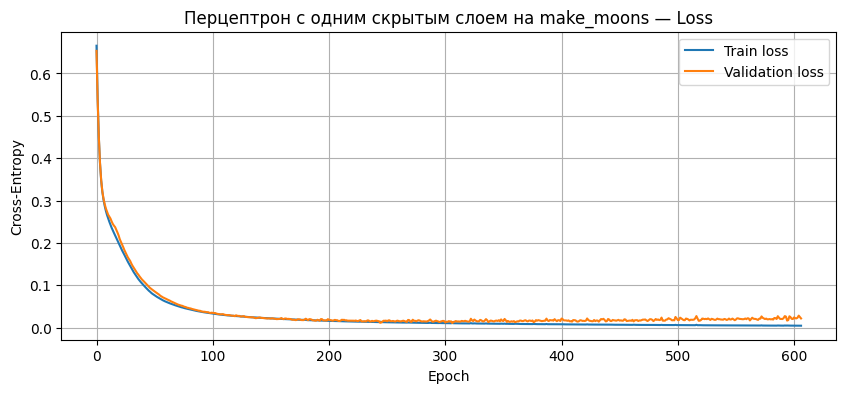

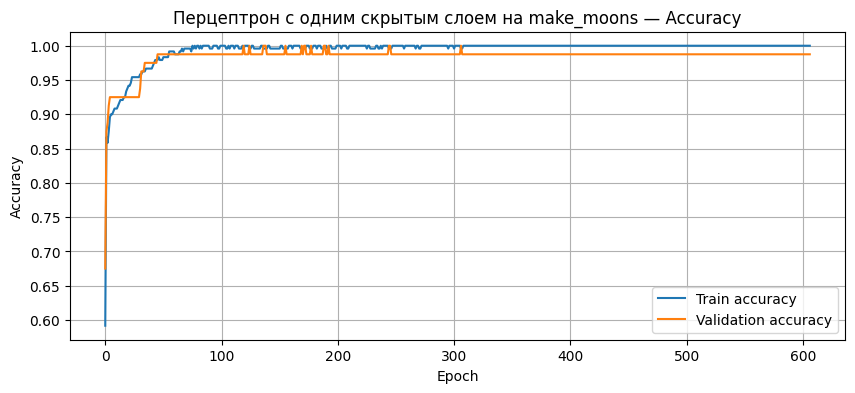

Перцептрон с одним скрытым слоем | make_moons
Test accuracy: 1.0

Confusion matrix:
[[40  0]
 [ 0 40]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [14]:
# Берём данные make_moons
X_train, X_val, X_test, y_train, y_val, y_test, scaler = moons_data

hidden_moons = OneHiddenLayerPerceptron(
    input_dim=X_train.shape[1],
    hidden_dim=12,
    seed=ISU
)

hidden_moons, hist_hidden_moons = train_model(
    hidden_moons,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=3000,
    batch_size=32,
    lr=0.01,
    optimizer_method="adam_modified",
    patience=300,
    verbose=True
)

plot_history(hist_hidden_moons, "Перцептрон с одним скрытым слоем на make_moons")

acc_hidden_moons = evaluate_model(
    hidden_moons,
    X_test,
    y_test,
    "Перцептрон с одним скрытым слоем | make_moons"
)

# Обучение на make_classification

## Однослойная сеть на make_classification

Epoch  100 | train_loss=0.5497 | val_loss=0.5659 | train_acc=0.5000 | val_acc=0.5000
Epoch  200 | train_loss=0.5468 | val_loss=0.5638 | train_acc=0.5000 | val_acc=0.5000
Early stopping на эпохе 210


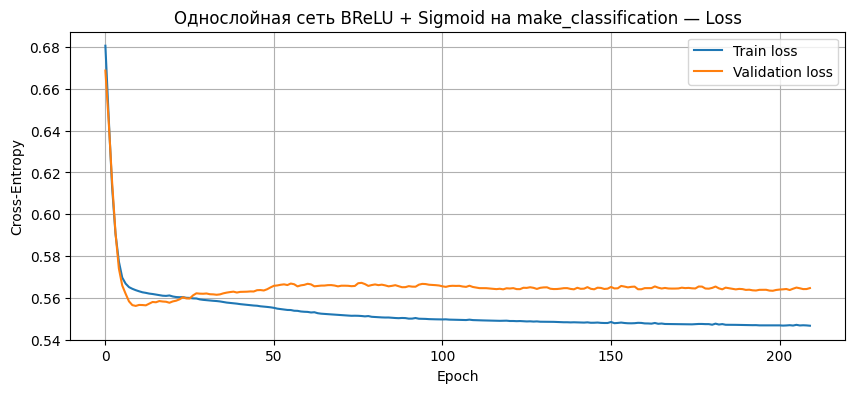

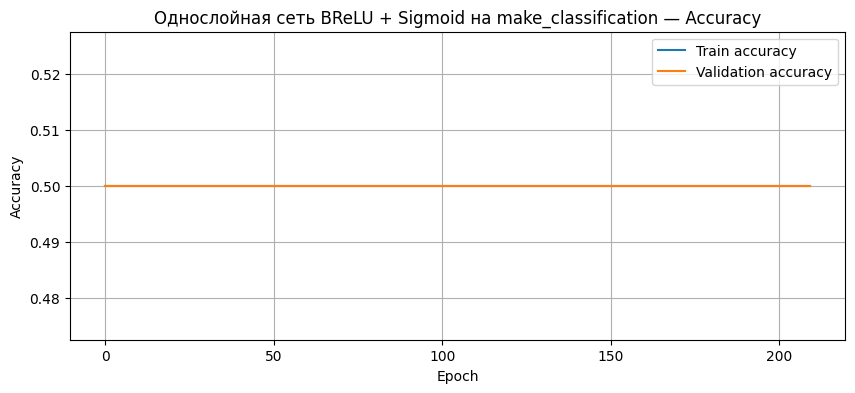

Однослойная сеть BReLU + Sigmoid | make_classification
Test accuracy: 0.5

Confusion matrix:
[[ 0 20]
 [ 0 20]]

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.50      1.00      0.67        20

    accuracy                           0.50        40
   macro avg       0.25      0.50      0.33        40
weighted avg       0.25      0.50      0.33        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
X_train, X_val, X_test, y_train, y_val, y_test, scaler = class_data

one_layer_class = OneLayerBReLUSigmoidNet(
    input_dim=X_train.shape[1],
    seed=ISU
)

one_layer_class, hist_one_layer_class = train_model(
    one_layer_class,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=2000,
    batch_size=16,
    lr=0.01,
    optimizer_method="adam_modified",
    patience=200,
    verbose=True
)

plot_history(hist_one_layer_class, "Однослойная сеть BReLU + Sigmoid на make_classification")

acc_one_layer_class = evaluate_model(
    one_layer_class,
    X_test,
    y_test,
    "Однослойная сеть BReLU + Sigmoid | make_classification"
)

## Перцептрон с одним скрытым слоем на make_classification

Epoch  100 | train_loss=0.1079 | val_loss=0.2336 | train_acc=0.9667 | val_acc=0.8500
Epoch  200 | train_loss=0.0599 | val_loss=0.2768 | train_acc=0.9833 | val_acc=0.9000
Epoch  300 | train_loss=0.0487 | val_loss=0.3197 | train_acc=0.9833 | val_acc=0.9000
Epoch  400 | train_loss=0.0405 | val_loss=0.3637 | train_acc=0.9833 | val_acc=0.9000
Early stopping на эпохе 413


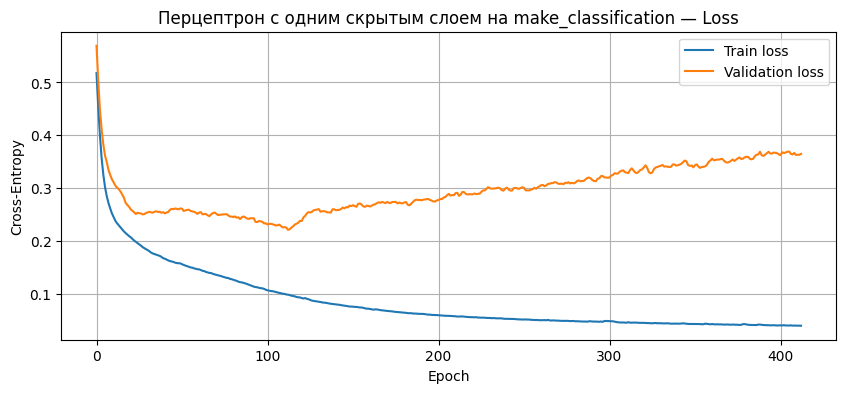

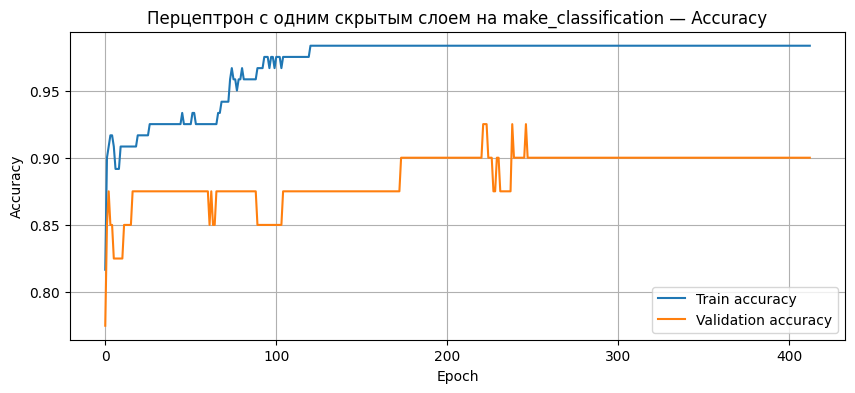

Перцептрон с одним скрытым слоем | make_classification
Test accuracy: 0.925

Confusion matrix:
[[20  0]
 [ 3 17]]

Classification report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        20
           1       1.00      0.85      0.92        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40



In [16]:
hidden_class = OneHiddenLayerPerceptron(
    input_dim=X_train.shape[1],
    hidden_dim=10,
    seed=ISU
)

hidden_class, hist_hidden_class = train_model(
    hidden_class,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=3000,
    batch_size=16,
    lr=0.01,
    optimizer_method="adam_modified",
    patience=300,
    verbose=True
)

plot_history(hist_hidden_class, "Перцептрон с одним скрытым слоем на make_classification")

acc_hidden_class = evaluate_model(
    hidden_class,
    X_test,
    y_test,
    "Перцептрон с одним скрытым слоем | make_classification"
)

Epoch  100 | train_loss=0.5536 | val_loss=0.5644 | train_acc=0.5000 | val_acc=0.5000
Epoch  200 | train_loss=0.5531 | val_loss=0.5669 | train_acc=0.5000 | val_acc=0.5000
Early stopping на эпохе 299


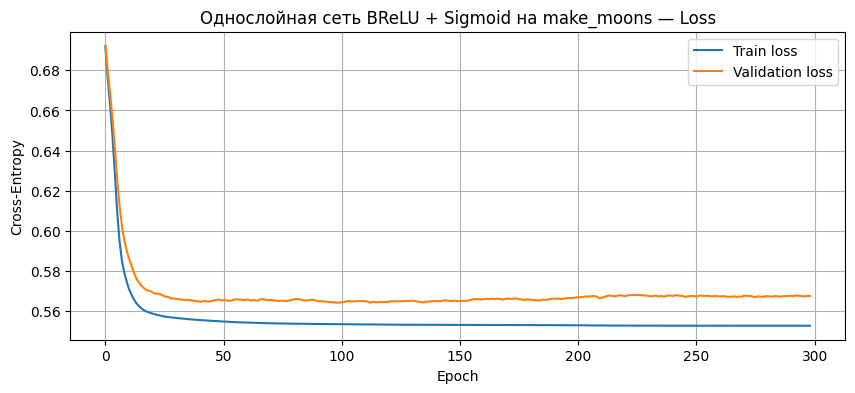

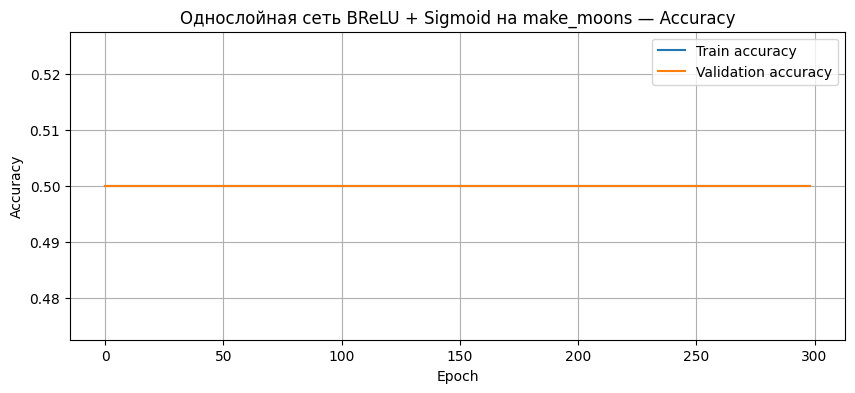

Однослойная сеть BReLU + Sigmoid | make_moons
Test accuracy: 0.5

Confusion matrix:
[[ 0 40]
 [ 0 40]]

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        40
           1       0.50      1.00      0.67        40

    accuracy                           0.50        80
   macro avg       0.25      0.50      0.33        80
weighted avg       0.25      0.50      0.33        80



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
X_train, X_val, X_test, y_train, y_val, y_test, scaler = moons_data

one_layer_moons = OneLayerBReLUSigmoidNet(
    input_dim=X_train.shape[1],
    seed=ISU
)

one_layer_moons, hist_one_layer_moons = train_model(
    one_layer_moons,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=2000,
    batch_size=32,
    lr=0.01,
    optimizer_method="adam_modified",
    patience=200,
    verbose=True
)

plot_history(hist_one_layer_moons, "Однослойная сеть BReLU + Sigmoid на make_moons")

acc_one_layer_moons = evaluate_model(
    one_layer_moons,
    X_test,
    y_test,
    "Однослойная сеть BReLU + Sigmoid | make_moons"
)

## Итоговая таблица результатов

In [20]:
import pandas as pd

needed_vars = [
    "acc_one_layer_moons",
    "acc_hidden_moons",
    "acc_one_layer_class",
    "acc_hidden_class"
]

for var in needed_vars:
    if var not in globals():
        print(f"Не создана переменная: {var}")

if all(var in globals() for var in needed_vars):
    results = {
        "Dataset": [
            "make_moons",
            "make_moons",
            "make_classification",
            "make_classification"
        ],
        "Model": [
            "Однослойная BReLU + Sigmoid",
            "Перцептрон с одним скрытым слоем",
            "Однослойная BReLU + Sigmoid",
            "Перцептрон с одним скрытым слоем"
        ],
        "Test accuracy": [
            acc_one_layer_moons,
            acc_hidden_moons,
            acc_one_layer_class,
            acc_hidden_class
        ]
    }

    results_df = pd.DataFrame(results)
    display(results_df)
else:
    print("Сначала дообучи и оцени модели, переменные которых указаны выше.")

,Dataset,Model,Test accuracy
0,make_moons,Однослойная BReLU + Sigmoid,0.500
1,make_moons,Перцептрон с одним скрытым слоем,1.000
2,make_classification,Однослойная BReLU + Sigmoid,0.500
3,make_classification,Перцептрон с одним скрытым слоем,0.925
